In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Load data
df = pd.read_csv('../data/processed/yrbs_cleaned_and_recoded.csv')

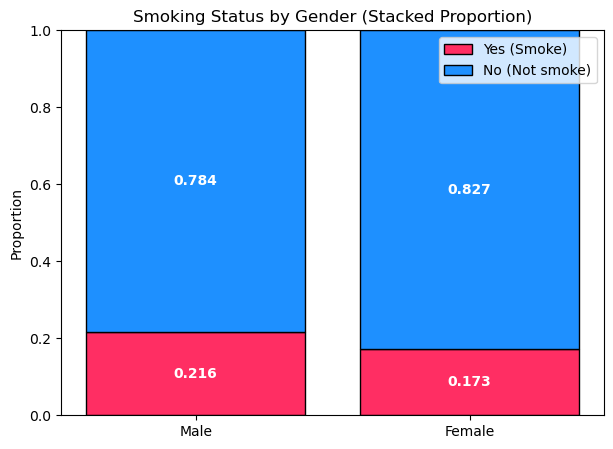

In [2]:
# PROPORTIONS

# Split data into two gender groups
male = df[df["WhatIsYourSex"] == 1]
female = df[df["WhatIsYourSex"] == 0]

# Calculate proportion of smokers (mean of binary variable)
male_yes = male["CurrentCigaretteUse"].mean()
female_yes = female["CurrentCigaretteUse"].mean()

# Calculate proportion of non-smokers
male_no = 1 - male_yes
female_no = 1 - female_yes

# STACKED BAR CHART

# Define group labels
labels = ["Male", "Female"]
x = np.arange(len(labels))

# Values for each category
yes_values = [male_yes, female_yes]
no_values = [male_no, female_no]

# Create figure
plt.figure(figsize=(7,5))

# Plot stacked bars (Yes on bottom, No on top)
plt.bar(x, yes_values, label="Yes (Smoke)", color="#FF2E63", edgecolor="black")
plt.bar(x, no_values, bottom=yes_values, label="No (Not smoke)", color="#1E90FF", edgecolor="black")

# Set axis labels and title
plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.title("Smoking Status by Gender (Stacked Proportion)")
plt.ylim(0, 1)

# Show legend
plt.legend()

# Add value labels inside bars
for i in range(len(x)):
    # Label for smokers (bottom part)
    plt.text(x[i], yes_values[i]/2, f"{yes_values[i]:.3f}",
             ha="center", va="center", color="white", fontweight="bold")

    # Label for non-smokers (top part)
    plt.text(x[i], yes_values[i] + no_values[i]/2, f"{no_values[i]:.3f}",
             ha="center", va="center", color="white", fontweight="bold")

# Display plot
plt.show()

Interpretation: 
This figure compares the proportion of current cigarette smoking between male and female students. The results show that there is a difference in
smoking rates between genders. Male students have a relatively higher proportion of current smoking, while female students have a higher proportion of non-smoking. This suggests that gender may be associated with smoking behavior.

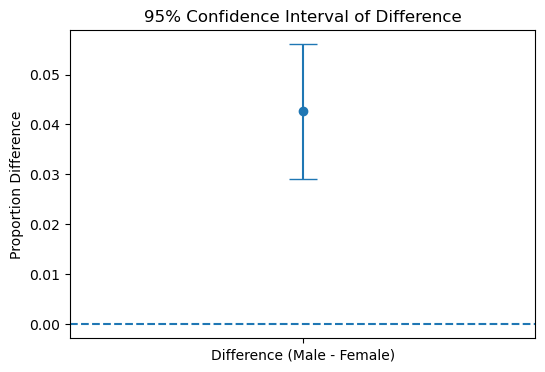

In [3]:
# Confidence Interval

# Split data into two gender groups
male = df[df["WhatIsYourSex"] == 1]
female = df[df["WhatIsYourSex"] == 0]

# Compute smoking rates (proportions)
male_rate = male["CurrentCigaretteUse"].mean()
female_rate = female["CurrentCigaretteUse"].mean()

# Difference & Confidence Interval

# Difference in proportions (Male - Female)
diff = male_rate - female_rate

# Standard error of difference in proportions
se = np.sqrt(
    (male_rate * (1 - male_rate)) / len(male) +
    (female_rate * (1 - female_rate)) / len(female)
)

# 95% confidence interval
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

# Plot confidence interval
plt.figure(figsize=(6,4))

# Error bar plot for CI
plt.errorbar(
    x=["Difference (Male - Female)"],
    y=[diff],
    yerr=[[diff - ci_lower], [ci_upper - diff]],
    fmt='o',
    capsize=10
)

# Reference line at 0 (no difference)
plt.axhline(0, linestyle="--")

# Titles and labels
plt.title("95% Confidence Interval of Difference")
plt.ylabel("Proportion Difference")

plt.show()

Interpretation:
From the figure, we observe that the difference in current smoking proportion (Male − Female) is positive, indicating that males have a higher smoking rate than females. Since the confidence interval does not cross 0, it suggests that the difference in smoking proportions between males and females is statistically significant, indicating a potential association between gender and smoking behavior.

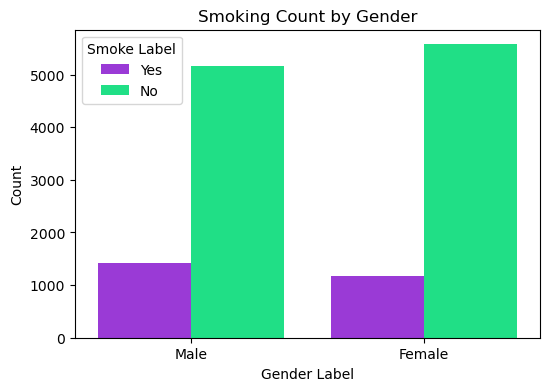

In [4]:
# Smoking Count

# Create readable labels for gender
df["Gender Label"] = df["WhatIsYourSex"].map({0: "Female", 1: "Male"})

# Create readable labels for smoking status
df["Smoke Label"] = df["CurrentCigaretteUse"].map({0: "No", 1: "Yes"})

# Set figure size
plt.figure(figsize=(6,4))

# Create count plot (grouped bar chart)
sns.countplot(
    data=df,
    x="Gender Label",
    hue="Smoke Label",
    palette={
       "Yes": "#A020F0",  # purple for smokers
       "No": "#00FF88"    # green for non-smokers
    }
)

# Add title and axis label
plt.title("Smoking Count by Gender")
plt.ylabel("Count")

# Show plot
plt.show()

Interpretation: 
This figure shows the distribution of the number of male and female students by current smoking status (Yes / No). The results show a clear difference in smoking behavior between genders. Male students have a higher number of current smokers, while female students are mainly non-smokers, suggesting that gender may be associated with smoking behavior.